In [29]:
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import tools_condition,ToolNode
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, AIMessage,ToolMessage
from operator import add
from langchain_core.tools import tool

In [2]:
llm=ChatOllama(model="llama3.2:1b")

In [3]:
@tool
def calculator_tool(expression:str)->str:
    """
    Evaluates a mathematical expression 
    Example :
    2+2
    2/4
    """
    return str(eval(expression))

In [4]:
Lm_with_tool=llm.bind_tools([calculator_tool])

In [5]:
class agent_state(TypedDict):
    request: str
    respose: str


In [38]:
def lmm_node(state:MessagesState)->MessagesState:
    request=state["messages"]

    response=Lm_with_tool.invoke(request)
    return {"messages":[response]}

    

In [39]:
graph=StateGraph(MessagesState)

In [40]:
graph.add_node("llm_node",lmm_node)
graph.add_node("tools",ToolNode([calculator_tool]))

In [41]:
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",tools_condition)
graph.add_edge("tools","llm_node")
graph.add_edge("llm_node",END)


In [42]:
app=graph.compile()

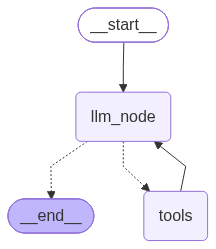

In [43]:
app

In [44]:
app.invoke({
        "messages": [("what is sum of 3 and 4")]
    })

{'messages': [HumanMessage(content='what is sum of 3 and 4', additional_kwargs={}, response_metadata={}, id='c7b460a5-e0f4-41ca-a1c6-ecb5380a0cce'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2026-07-23T09:58:08.9275155Z', 'done': True, 'done_reason': 'stop', 'total_duration': 66007303200, 'load_duration': 32629239700, 'prompt_eval_count': 170, 'prompt_eval_duration': 17582565000, 'eval_count': 43, 'eval_duration': 15696113000, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--019f8e68-390b-7891-97c3-1b6669922587-0', tool_calls=[{'name': 'calculator_tool', 'args': {'type': 'object', 'required': ['expression'], 'properties': {'expression': 'sum of 3 and 4'}}, 'id': '7b65ad7f-fc26-440e-a0f4-8db19839456b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 43, 'total_tokens': 213}),
  ToolMessage(content="Error invoking tool 'calculator_tool' 